In [7]:
# Importing Libraries
import seaborn as sns
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [8]:
df_DS_USA= df[(df['job_country']=='United States') &(df['job_title_short']== 'Data Scientist')]
df_DS_USA = df_DS_USA.dropna(subset='salary_year_avg')

In [9]:
df_DS_USA= df_DS_USA.explode('job_skills')

df_DS_top_pay= df_DS_USA.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending= False).head(10)

df_DS_skills= df_DS_USA.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending= False).head(10)

df_DS_skills= df_DS_skills.sort_values(by='median', ascending=False)

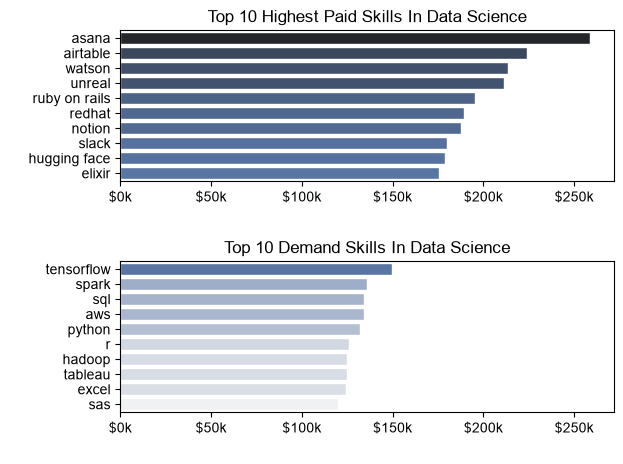

<Figure size 1000x600 with 0 Axes>

In [10]:
fig, ax= plt.subplots(2,1)
plt.figure(figsize=(10, 6))
sns.set_theme(style='ticks')
sns.barplot(data=df_DS_top_pay, x='median', y=df_DS_top_pay.index, ax=ax[0], hue= 'median', palette='dark:b_r')
#ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills In Data Science')
ax[0].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k')
ax[0].set_xlabel(' ')
ax[0].set_ylabel(' ')
ax[0].legend().remove()

sns.barplot(data=df_DS_skills, x='median', y=df_DS_skills.index, ax=ax[1],hue= 'median', palette='light:b')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Demand Skills In Data Science')
ax[1].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k')
ax[1].set_xlabel(' ')
ax[1].set_ylabel(' ')
ax[1].legend().remove()

fig.tight_layout()

In [11]:
from pathlib import Path

image_folder = Path(r"C:\Users\PC\Desktop\vscode_python\3_Project\image")
image_folder.mkdir(parents=True, exist_ok=True)

fig.savefig(image_folder / "median_salary_skills.png", dpi=300, bbox_inches="tight")
plt.show()